In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate
import math
import lab_funcs as lf
import my_funcs as mf

# Методы Монте-Карло

## Задание 1
1. Вычислите методом Монте-Карло объемы $D$-мерных шаров радиуса $R=1$ для $D=1\ldots 15$ с выборками размера $N=1\ldots 10^6$.
Постройте график зависимости средней квадратической относительной ошибки объема от $N$ для разных $D$. Оцените асимптотику ошибки при $N\to\infty$.

2. Теоретически обоснуйте наблюдаемую зависимость средней квадратической ошибки от размера выборки.

3. Как можно оценить предельную ошибку вычисления интеграла методом Монте-Карло?

4. Сравните ошибку метода Монте-Карло с результатами лабораторной [про квадратурные формулы](Integration.ipynb). Для каких размерностей $D$ метод Монте-Карло оказывается точнее, чем вычисление через произведение составных формул Симпсона по каждой из координат?

### Решение 1

#### 1.

Данные интегралы считаются через метод Монте-Карло. Краткая идея состоит в том, что матожидание есть интеграл, и к матожиданию стремится среднее выборки случайных величи по ЗБЧ. И тем самым сгенерировав достаточную выборку, мы можем оценить или даже вычислить интеграл. Приведем выкладки:

$$
E_p[f] = \int_{\Omega} f(x)p(x) dx
$$

$$
E_p[f] \approx M_N = \frac{1}{N}\sum_{n=1}^N f(x_n),
$$

---
ЗБЧ:

Пусть $X_1, X_2, \dots, X_N$ — независимые одинаково распределённые случайные величины с математическим ожиданием $E[X_i] = \mu$.

Тогда их среднее:

$$
M_N = \frac{1}{N} \sum_{k=1}^{N} X_k
$$

сходится к математическому ожиданию:

$$
M_N \xrightarrow[N \to \infty]{} \mu
$$

(сходимость по вероятности — слабый закон больших чисел)


ЦПТ:

Пусть дополнительно дисперсия конечна: $\mathrm{Var}(X_i) = \sigma^2$.

Тогда

$$
\sqrt{N}\left(M_N - \mu\right)
\xrightarrow[N \to \infty]{d}
\mathcal{N}(0, \sigma^2)
$$

или эквивалентно:

$$
M_N \approx \mathcal{N}\left(\mu, \frac{\sigma^2}{N}\right)
$$


Для оценки интеграла:

$$
\frac{1}{N} \sum_{k=1}^{N} f(x_k)
$$

ошибка имеет порядок:

$$
\text{ошибка} \sim O\left(\frac{1}{\sqrt{N}}\right)
$$

и стандартное отклонение:

$$
\sigma(M_N) = \frac{\sigma}{\sqrt{N}}
$$

---

Для вычисления обьема $D$ шара $B=\{x\in\mathbb R^D\colon |x|^2\leq 1\},$
мы возьмем случайную величину $X$ равномерно распределенную на кубе $\Omega=[-1,1]^{\times D}$.
Воспользуемся очевидными тождествами:
$$
\frac{V(B)}{V(\Omega)}=P\{X\in B\}=E[1_B],
$$
где $1_B$ - характеристическая функция множества $B$:

$$
1_B(x)=\begin{cases}
1,&x\in B,\\
0,&x\notin B.
\end{cases}
$$

$$p(x) = \frac{1}{V(\Omega)}$$

$$E[1_B] = \int_{\Omega} 1_B(x) p(x) dx = \frac{1}{V(\Omega)} \cdot \int_{\Omega} 1_B(x)dx$$

$$V(B) = \int_{\Omega} 1_B(x)dx$$

Проинтегрируем и получим графики для объемов $D$-мерных шаров радиуса $R=1$ для $D=1\ldots 15$ с выборками размера $N=1\ldots 10^6$

/tmp/ipykernel_36154/1933031629.py:85: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.tight_layout()


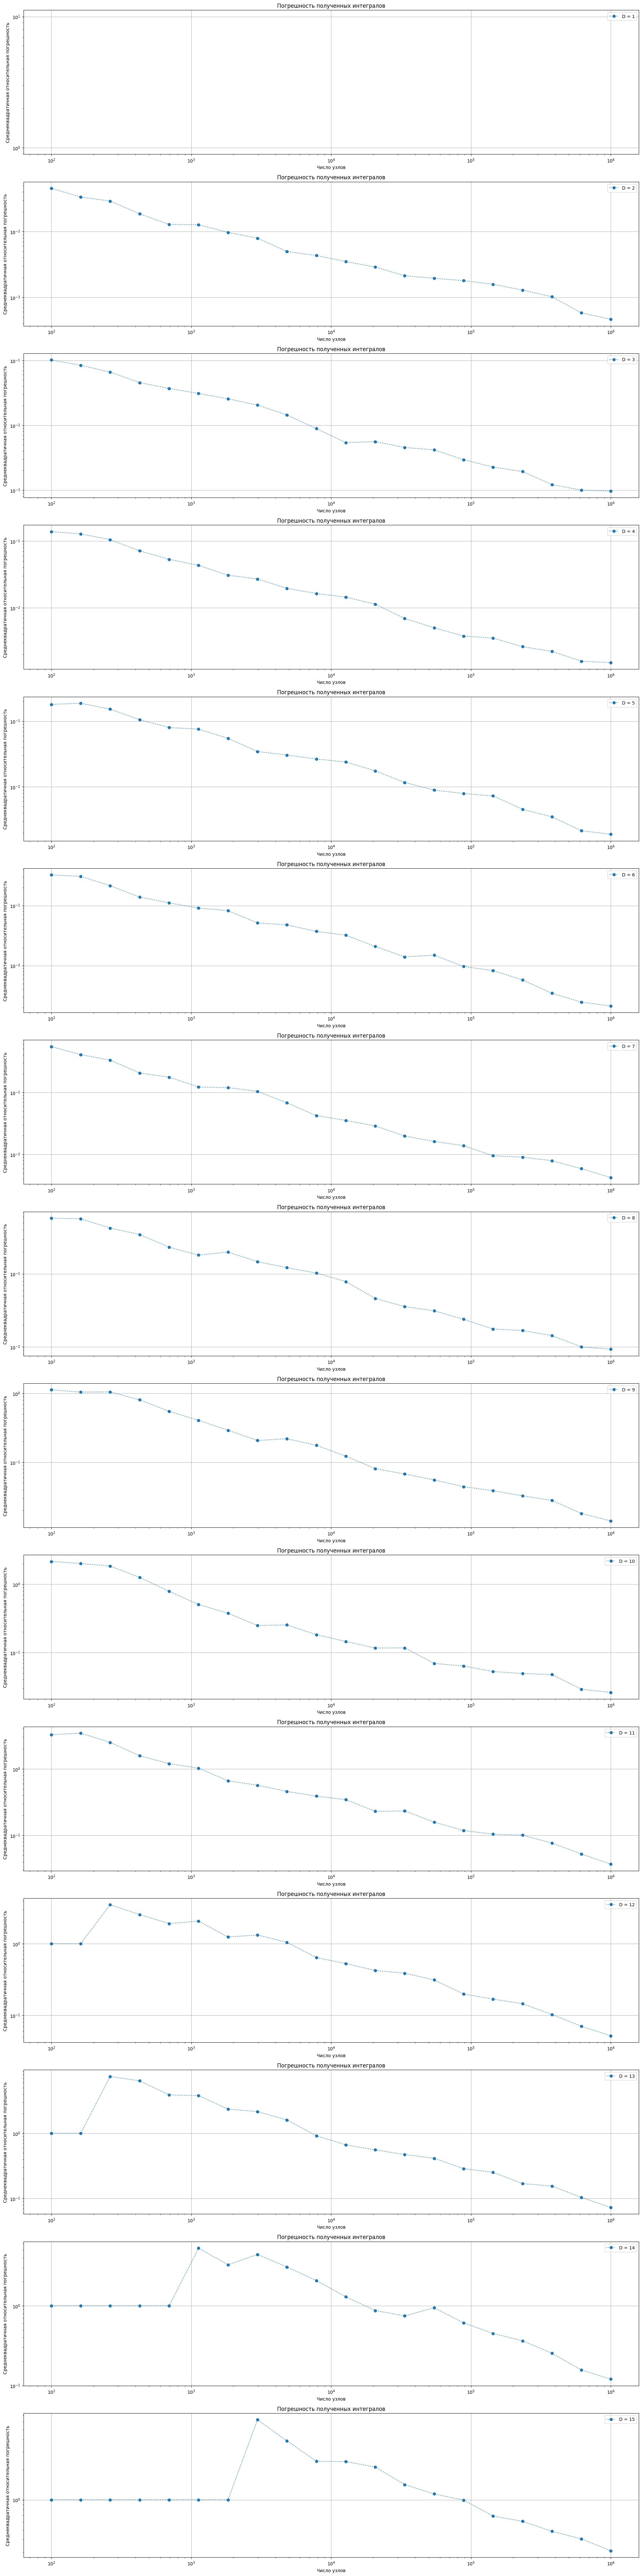

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
import lab_funcs as lf


def get_volume_of_N_dim_ball_by_theor(n, R):
    return (np.power(np.pi, (n / 2)) / gamma(n / 2 + 1)) * (np.power(R,n))


def get_volume_of_n_dim_ball_by_Monte_Carlo(dim_s, R, sz_sequences, rand_sequences):
    """
    dim_s         : массив размерностей, например [1, 2, ..., 10]
    R             : радиус шара
    sz_sequences  : массив количеств точек N
    rand_sequences: массив случайных координат формы (max_dim, max_N)
    """

    # накопленные суммы квадратов координат:
    # строка i содержит ||x||^2 для размерности i+1
    sum_sq = np.cumsum(rand_sequences ** 2, axis=0)  # shape = (max_dim, max_N)

    # для каждой размерности проверяем попадание в шар
    is_x_in_B = sum_sq[dim_s - 1, :] < R**2  # shape = (len(dim_s), max_N)

    # число попаданий среди первых N точек
    x_in_B_count = np.cumsum(is_x_in_B, axis=1)[:, sz_sequences - 1]

    statistic_mean_bin_val = x_in_B_count / sz_sequences

    V_Omega = np.power((2 * R), dim_s)
    V_Omega = V_Omega[:, np.newaxis]

    V_B_estimated = statistic_mean_bin_val * V_Omega

    return V_B_estimated


# set params
D = np.arange(1, 16)                  # размерности от 1 до 15
N = np.logspace(2, 6, num=20, dtype=int)
R = 1

# generate random sequence
numb_iteration = 20
max_D = D.max()
max_N = N.max()

# shape: (число прогонов, max_dim, max_N)
rand_sequences = np.random.rand(numb_iteration, max_D, max_N) * 2 - 1

# find volumes
data_all = np.zeros((numb_iteration, D.size, N.size))

for num_iter_in_arr in range(numb_iteration):
    data_all[num_iter_in_arr] = get_volume_of_n_dim_ball_by_Monte_Carlo(
        D, R, N, rand_sequences[num_iter_in_arr]
    )

data_mean = data_all.mean(axis=0)

volume_theor = get_volume_of_N_dim_ball_by_theor(D, R)

# find relative RMS errors
data_rms_err = np.empty((D.size, N.size))

for num_D in range(D.size):
    for num_N in range(N.size):
        data_rms_err[num_D, num_N] = lf.get_rmse_rel_err(
            data_all[:, num_D, num_N],
            volume_theor[num_D]
        )

# plot
fig, ax = plt.subplots(D.size, 1, figsize=(20, 80))

for num_dim in range(D.size):
    ax[num_dim].loglog(N, data_rms_err[num_dim], label=f"D = {D[num_dim]}", marker='o', linestyle=':')
    ax[num_dim].set_xlabel('Число узлов')
    ax[num_dim].set_ylabel('Среднеквадратичная относительная погрешность')
    ax[num_dim].set_title('Погрешность полученных интегралов')
    ax[num_dim].legend()
    ax[num_dim].grid(True)

fig.tight_layout()
plt.show()

#### 2.

Для теоретического обосования, почему погрешность зависит от дисперсии случайной величины, приведем следующие выкладки:



Рассмотрим вычисление объёма $D$-мерного шара методом Монте-Карло. Пусть $\Omega = [-1,1]^D$ — гиперкуб объёма $V_\Omega = 2^D$, внутри которого расположен шар объёма $V_D$.

Введём индикаторную функцию:
$$
\chi(x) =
\begin{cases}
1, & x \in B, \\
0, & x \notin B.
\end{cases}
$$

Тогда:
$$
E[\chi(x)] = \frac{V_D}{2^D}.
$$

Оценка объёма:
$$
\widehat V_D = 2^D \cdot \frac{1}{N} \sum_{k=1}^N \chi(x_k).
$$

---

##### Дисперсия и СКО

Так как $\chi(x)$ — бернуллиевская случайная величина:
$$
\mathrm{Var}(\chi) = p(1-p), \quad p = \frac{V_D}{2^D}.
$$

Отсюда:
$$
\mathrm{Var}(\chi) = \frac{V_D(2^D - V_D)}{2^{2D}}.
$$

Дисперсия оценки:
$$
\mathrm{Var}(\widehat V_D) = (2^D)^2 \cdot \frac{\mathrm{Var}(\chi)}{N}
= \frac{V_D(2^D - V_D)}{N}.
$$

Среднеквадратическое отклонение:
$$
\sigma(\widehat V_D) = \sqrt{\frac{V_D(2^D - V_D)}{N}}.
$$

---

##### Вывод

Среднеквадратическая ошибка метода Монте-Карло убывает как:
$$
\sigma(\widehat V_D) \sim \frac{1}{\sqrt{N}}.
$$

Это означает, что для уменьшения ошибки в $k$ раз необходимо увеличить число точек примерно в $k^2$ раз.

<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_36154/2649392804.py:2: SyntaxWarning: invalid escape sequence '\h'
  """
/tmp/ipykernel_36154/2649392804.py:26: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.tight_layout()


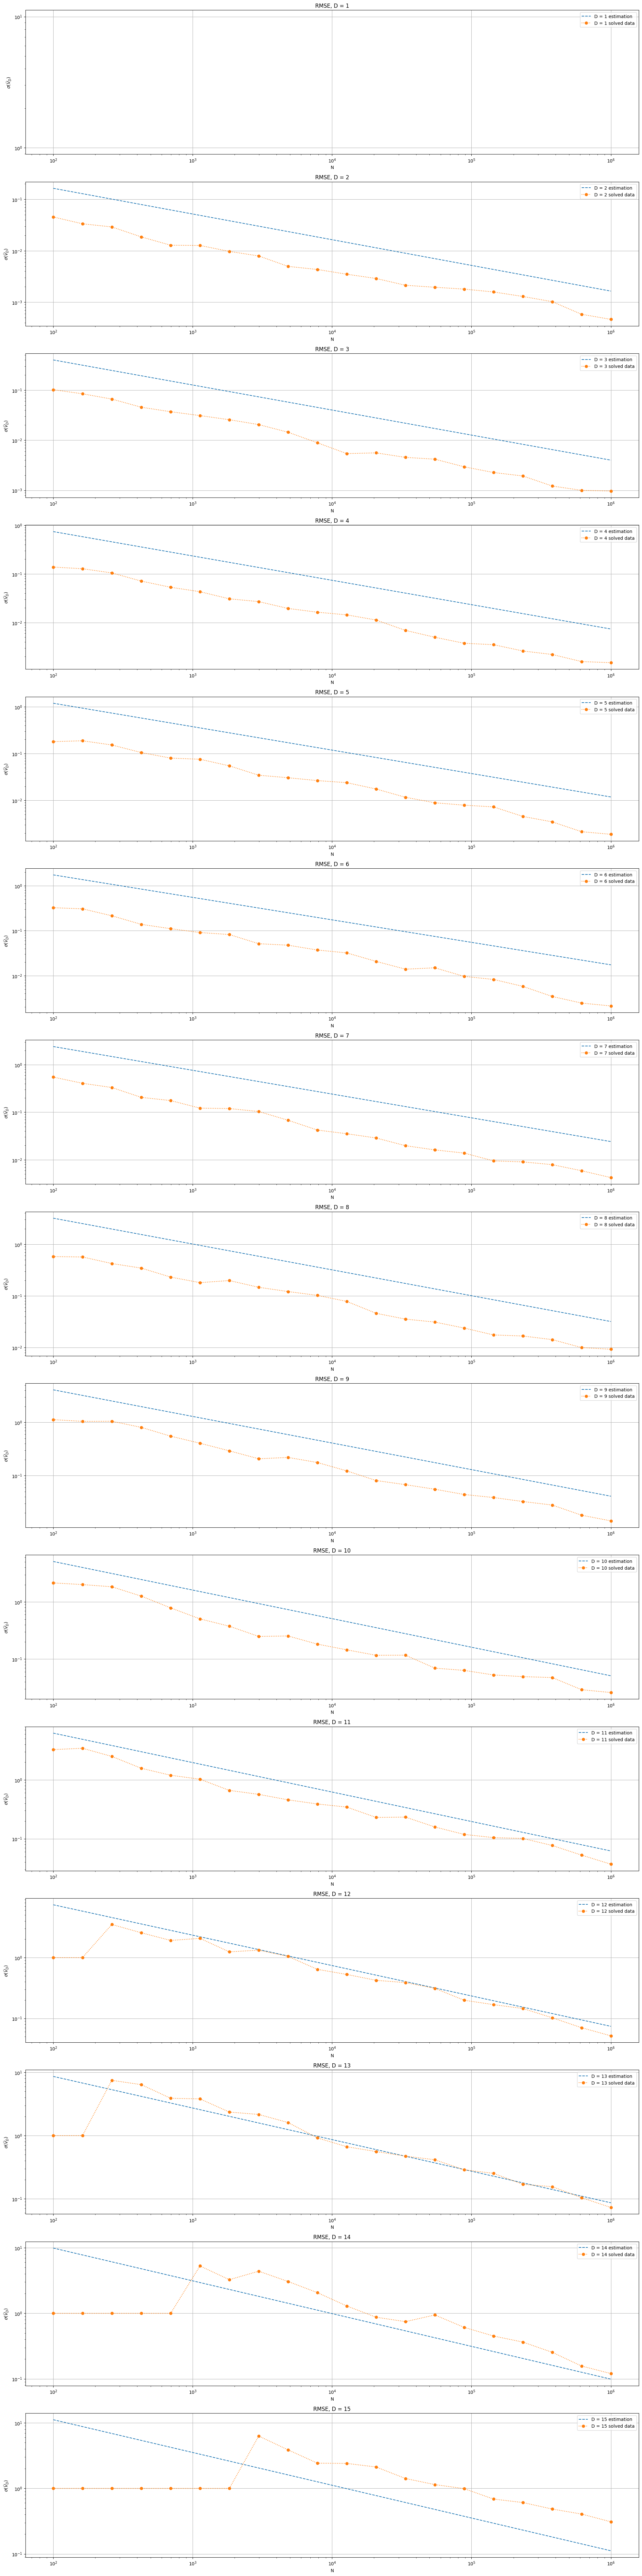

In [3]:
def get_sigma_volume_estimate(D, N, R=1):
    """
    Возвращает массив sigma shape = (len(D), len(N)),
    где для каждой размерности D считается
    sigma(\hat V_D) = sqrt(V_D * (2^D - V_D) / N)
    """
    V_D = get_volume_of_N_dim_ball_by_theor(D, R)   # shape = (len(D),)
    sigma = np.sqrt(V_D[:, np.newaxis] * ((np.power(2,D))[:, np.newaxis] - V_D[:, np.newaxis]) / N[np.newaxis, :])
    return sigma

# вычисление sigma
sigma_data = get_sigma_volume_estimate(D, N, R)

# графики
fig, ax = plt.subplots(len(D), 1, figsize=(20, 80))

for i in range(len(D)):
    ax[i].loglog(N, sigma_data[i], label=f"D = {D[i]} estimation", linestyle='--')
    ax[i].loglog(N, data_rms_err[i], label=f"D = {D[i]} solved data", marker='o', linestyle=':')
    ax[i].set_xlabel("N")
    ax[i].set_ylabel(r"$\sigma(\widehat V_D)$")
    ax[i].set_title(f"RMSE, D = {D[i]}")
    ax[i].grid(True)
    ax[i].legend()

fig.tight_layout()
plt.show()

#### 3.

##### Предельная ошибка метода Монте-Карло

##### Определение

Предельная ошибка — это максимально возможное отклонение оценки от истинного значения:
$$
\Delta_{\max} = \max |\widehat V_D - V_D|.
$$

---

##### Оценка метода

Оценка объёма:
$$
\widehat V_D = 2^D \cdot \frac{1}{N}\sum_{k=1}^N \chi(x_k), \quad \chi(x_k)\in\{0,1\}.
$$

Следовательно:
$$
0 \le \widehat V_D \le 2^D.
$$

---

##### Крайние случаи

1. Все точки попали в шар:
$$
\widehat V_D = 2^D, \quad |\widehat V_D - V_D| = |2^D - V_D|.
$$

2. Ни одна точка не попала:
$$
\widehat V_D = 0, \quad |\widehat V_D - V_D| = |V_D|.
$$

---

##### Итоговая оценка
Данная оценка служит верхней границей для численного метода
$$
\Delta_{\max} = \max\left(V_D,\; 2^D - V_D\right), \quad \Delta_{\max} \le 2^D.
$$

---


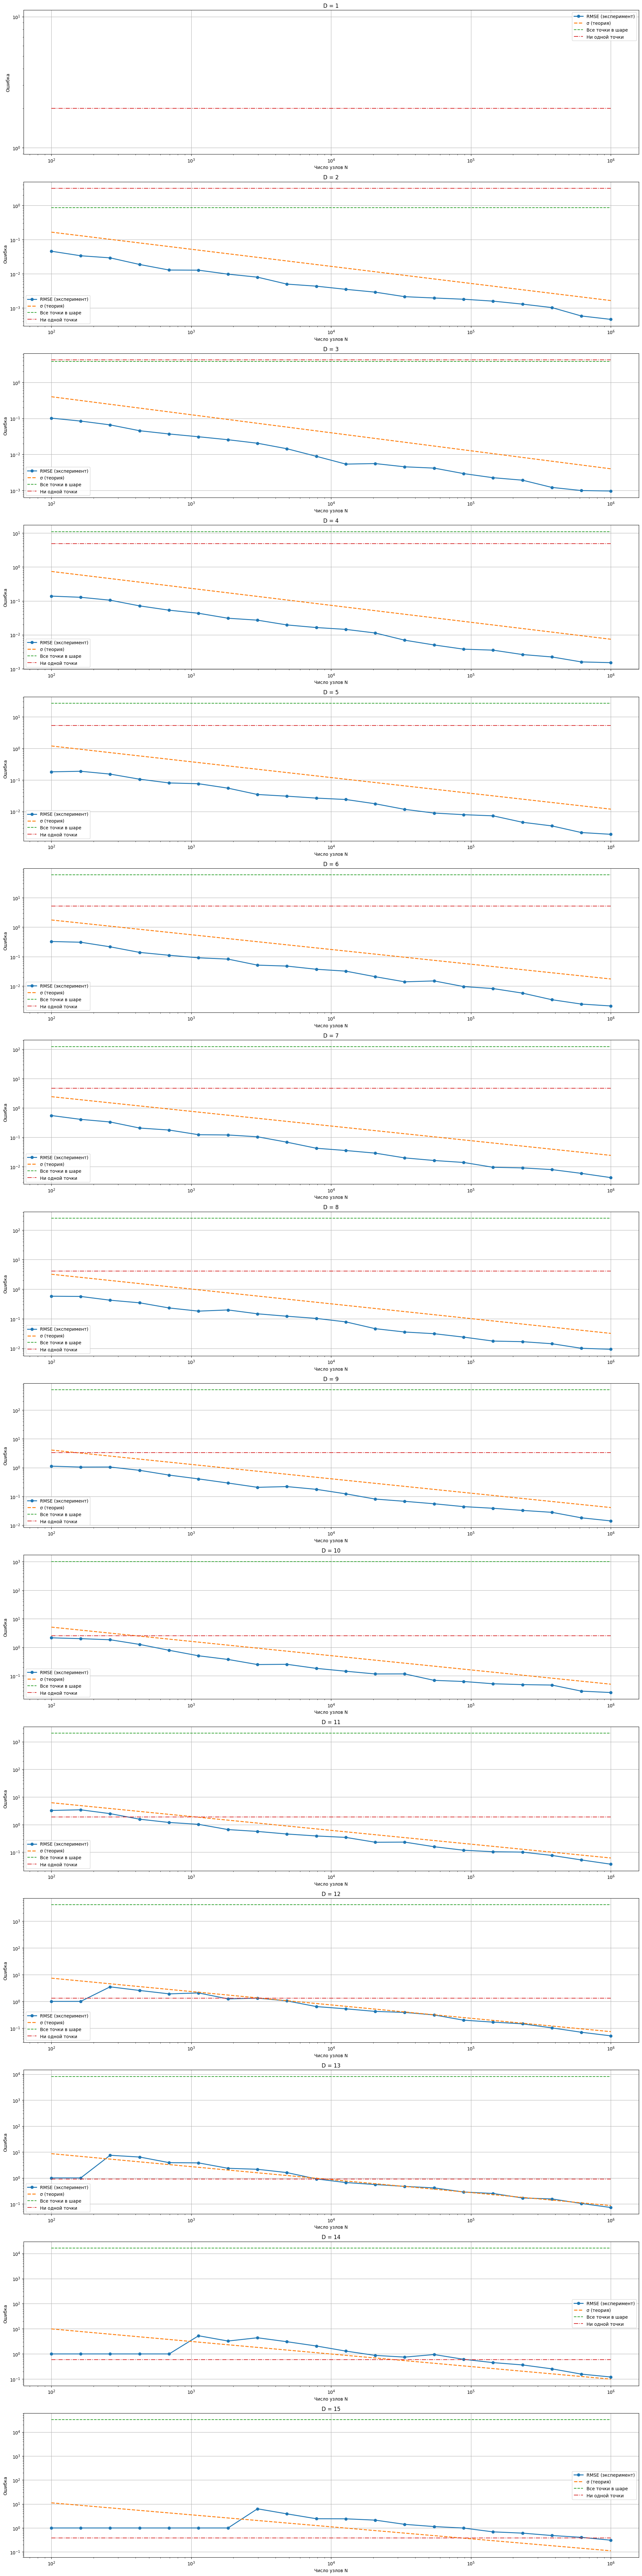

In [4]:

# теоретический объём
V_D = get_volume_of_N_dim_ball_by_theor(D, R)


# предельные случаи
err_all_inside = np.abs(2**D - V_D)
err_none_inside = np.abs(V_D)

# приведение к (D, N)
err_all_inside = err_all_inside[:, np.newaxis] * np.ones((1, N.size))
err_none_inside = err_none_inside[:, np.newaxis] * np.ones((1, N.size))


# === ГРАФИКИ ===
fig, ax = plt.subplots(len(D), 1, figsize=(20, 80))

for i in range(len(D)):

    # RMSE (уже посчитанная ранее)
    ax[i].loglog(N, data_rms_err[i], label="RMSE (эксперимент)", linewidth=2, marker='o')

    # теоретическая sigma
    ax[i].loglog(N, sigma_data[i], label="σ (теория)", linewidth=2, linestyle='--')

    # предельные случаи
    ax[i].loglog(N, err_all_inside[i], label="Все точки в шаре", linestyle='--')
    ax[i].loglog(N, err_none_inside[i], label="Ни одной точки", linestyle='-.')

    ax[i].set_xlabel("Число узлов N")
    ax[i].set_ylabel("Ошибка")
    ax[i].set_title(f"D = {D[i]}")
    ax[i].grid(True)
    ax[i].legend()

fig.tight_layout()
plt.show()

#### Сравнение ошибки Монте-Карло и составной формулы трапеций

Пусть число вычислений подынтегральной функции равно $N$.

---

##### Метод Монте-Карло

Среднеквадратическая ошибка:
$$
\varepsilon_{MC} \sim \frac{1}{\sqrt{N}} = N^{-1/2}.
$$

---

##### Составная формула трапеций в многомерном случае

В одномерном случае формула трапеций имеет погрешность порядка:
$$
\varepsilon_T \sim h^2,
$$
где $h$ — шаг сетки.

В $D$-мерном случае (произведение формул по координатам):
$$
N \sim h^{-D} \;\Rightarrow\; h \sim N^{-1/D}.
$$

Тогда:
$$
\varepsilon_T \sim h^2 \sim N^{-2/D}.
$$

---

##### Сравнение скоростей убывания ошибки

$$
\varepsilon_{MC} \sim N^{-1/2}, \qquad \varepsilon_T \sim N^{-2/D}.
$$

Сравниваем показатели:

- Монте-Карло: $1/2$  
- Трапеции: $2/D$

Метод Монте-Карло лучше, если:
$$
\frac{1}{2} > \frac{2}{D}
\;\Rightarrow\;
D > 4.
$$

---

##### Итог

- при $D < 4$ формула трапеций точнее  
- при $D = 4$ одинаковый порядок:
$$
\varepsilon \sim N^{-1/2}
$$
- при $D > 4$ метод Монте-Карло становится выгоднее  

---

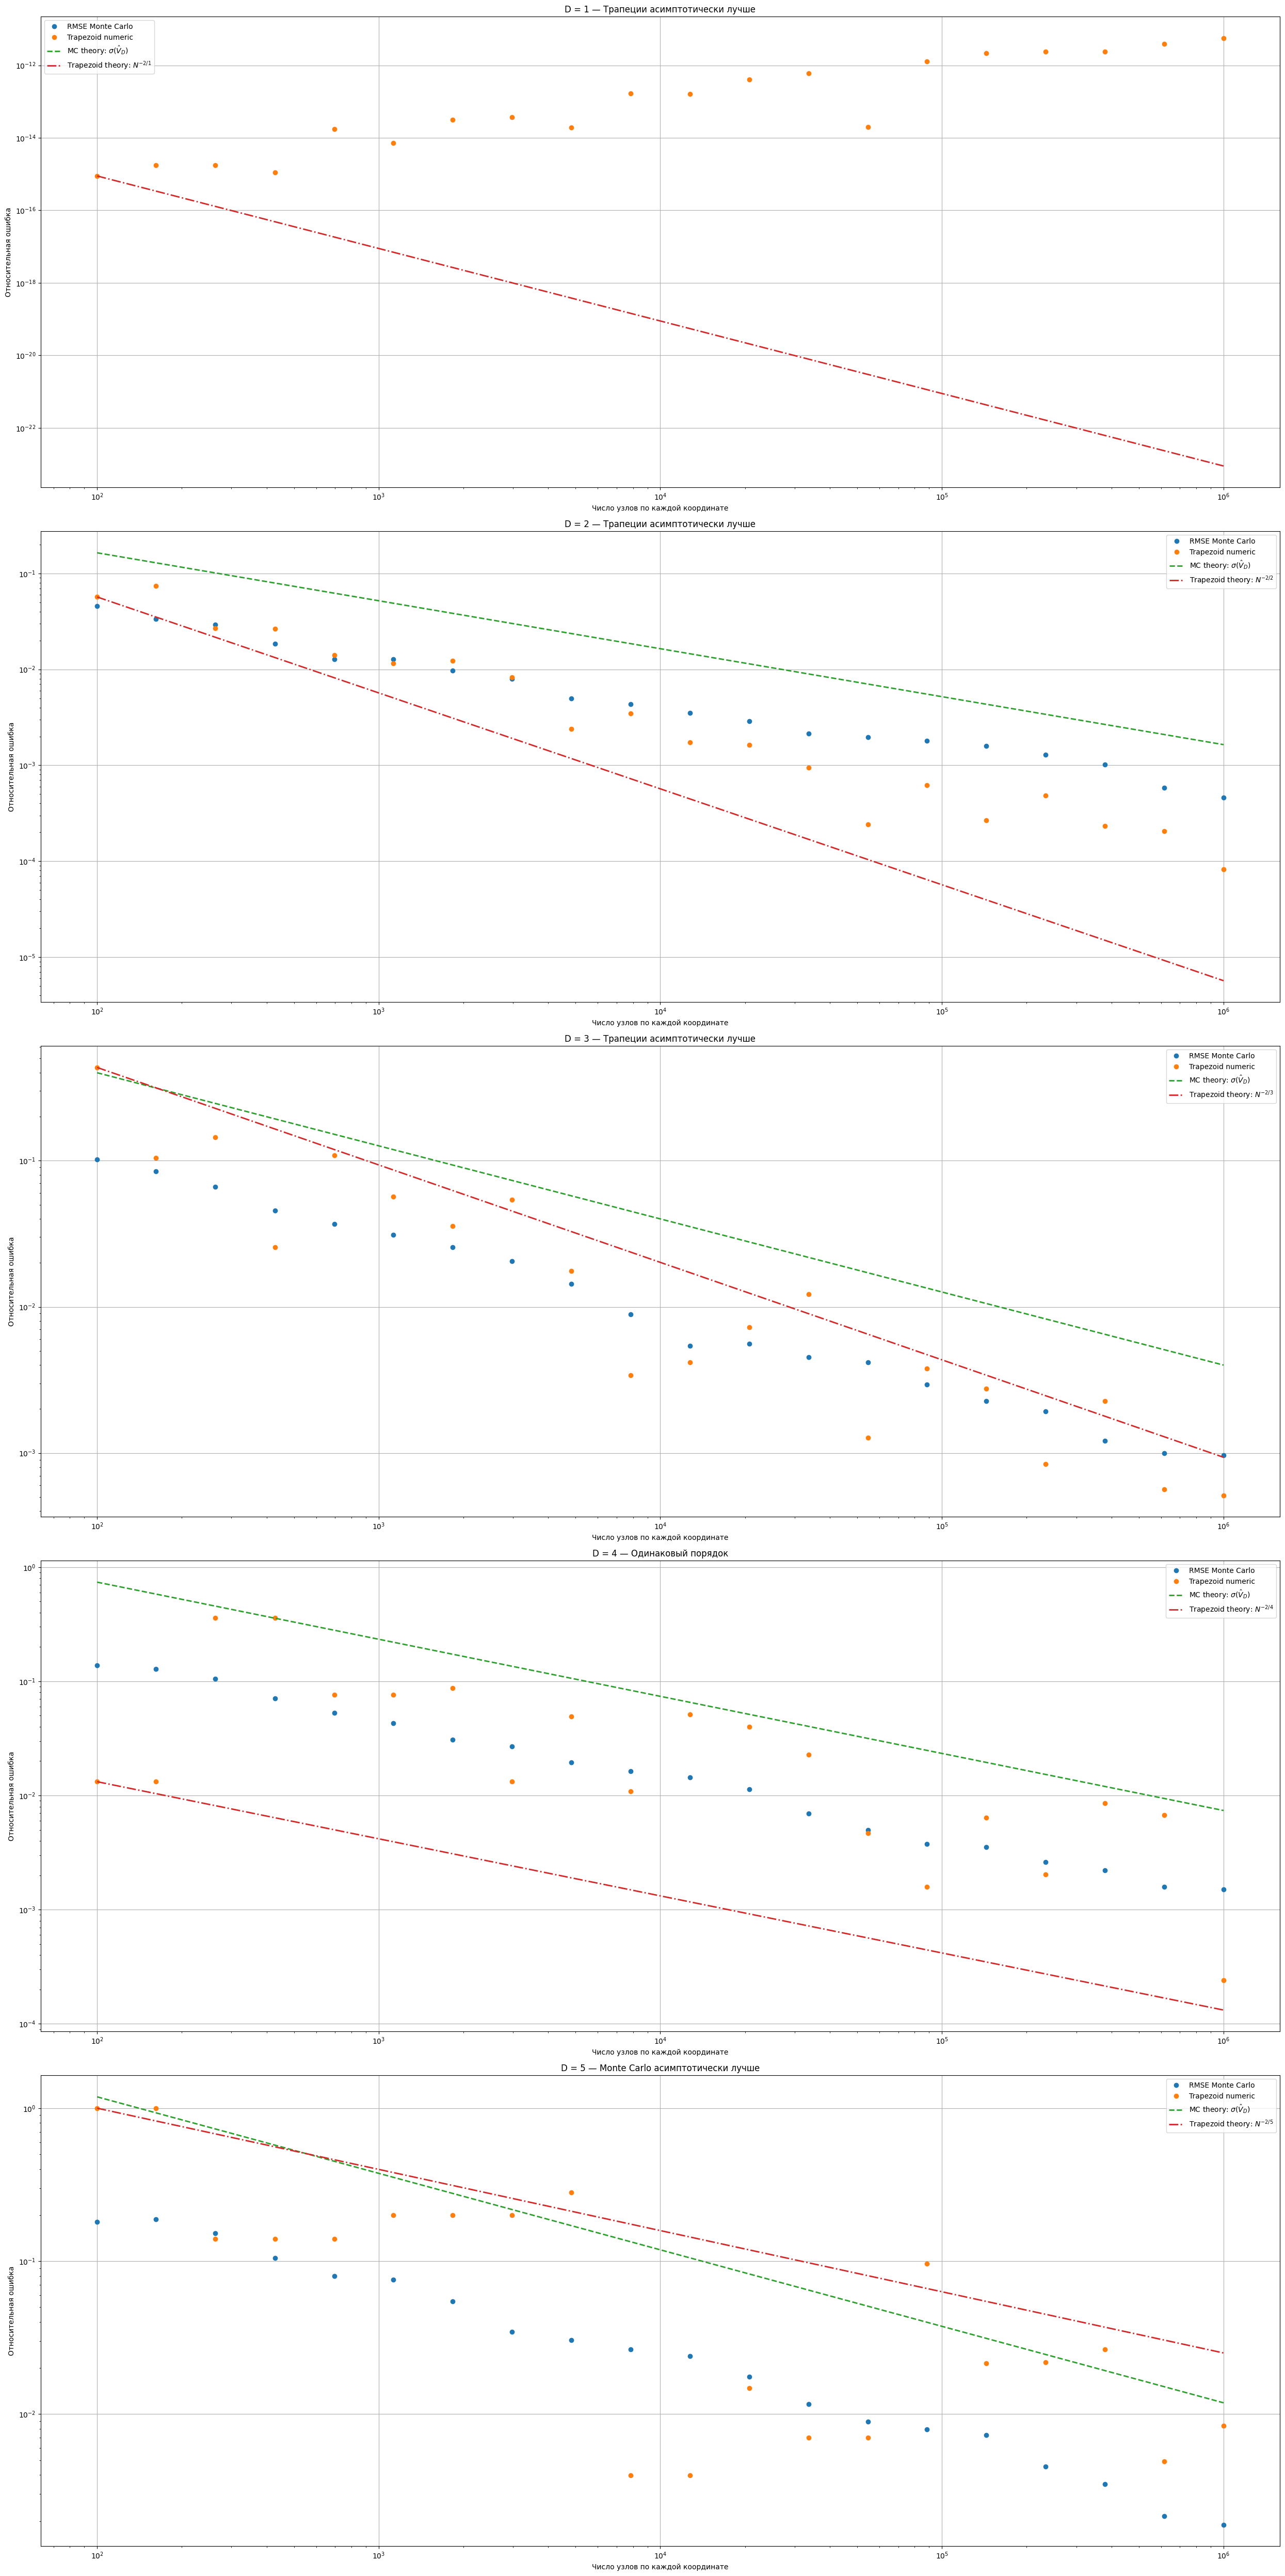

In [11]:
def get_volume_by_trapezoid_tensor_mesh(dim, R, n_nodes_1d):
    """
    Честное D-мерное интегрирование по произведению формул трапеций
    через полную тензорную сетку.
    """
    if dim < 1:
        raise ValueError("dim должно быть >= 1")
    if n_nodes_1d < 2:
        raise ValueError("Для формулы трапеций нужно хотя бы 2 узла")

    x = np.linspace(-R, R, n_nodes_1d)
    h = x[1] - x[0]

    w_1d = np.ones(n_nodes_1d, dtype=float)
    w_1d[0] = 0.5
    w_1d[-1] = 0.5

    grids = np.meshgrid(*([x] * dim), indexing='ij')
    weight_grids = np.meshgrid(*([w_1d] * dim), indexing='ij')

    sum_sq = np.zeros_like(grids[0], dtype=float)
    weight_prod = np.ones_like(grids[0], dtype=float)

    for g in grids:
        sum_sq += g**2

    for wg in weight_grids:
        weight_prod *= wg

    indicator = (sum_sq <= R**2).astype(float)

    return (h ** dim) * np.sum(weight_prod * indicator)


# -----------------------------
# параметры
# -----------------------------
D = np.arange(1, 6)
R = 1

# уменьшаем количество точек:
N_new = N

# для трапеций используем только уменьшенный набор
N_trap = N_new.copy()

# для трапеций нужно хотя бы 2 узла
N_trap = N_trap[N_trap >= 2]

# если после logspace появились повторы — убираем
N_trap = np.unique(N_trap)

# индексы этих точек в исходном массиве N
mc_idx = np.searchsorted(N, N_trap)

# теоретические объёмы
V_theor = get_volume_of_N_dim_ball_by_theor(D, R)

# -----------------------------
# численная ошибка трапеций
# -----------------------------
trap_err = np.zeros((len(D), len(N_trap)))

for i, dim in enumerate(D):
    for j, n_nodes in enumerate(N_trap):
        V_trap = get_volume_by_trapezoid_tensor_mesh(dim, R, np.power(n_nodes, (1/dim)).astype(int))
        trap_err[i, j] = lf.get_rel_err(V_trap, V_theor[i])

# -----------------------------
# графики
# -----------------------------
fig, ax = plt.subplots(len(D), 1, figsize=(25, 50))

if len(D) == 1:
    ax = [ax]

for i, dim in enumerate(D):
    rmse_mc = data_rms_err[dim - 1]
    rmse_mc_subset = rmse_mc[mc_idx]

    # теоретическая кривая Монте-Карло только в тех же точках
    mc_asympt = sigma_data[dim - 1][mc_idx]

    # теоретическая асимптотика трапеций
    trap_asympt = N_trap.astype(float) ** (-2 / dim)

    # нормировка теоретической кривой трапеций
    trap_asympt *= trap_err[i, 0] / trap_asympt[0]

    ax[i].loglog(N_trap, rmse_mc_subset, label='RMSE Monte Carlo', linewidth=0, marker='o')
    ax[i].loglog(N_trap, trap_err[i], label='Trapezoid numeric', linewidth=0, marker='o')
    ax[i].loglog(N_trap, mc_asympt, '--', label=r'MC theory: $\sigma(\hat V_D)$', linewidth=2)
    ax[i].loglog(N_trap, trap_asympt, '-.', label=rf'Trapezoid theory: $N^{{-2/{dim}}}$', linewidth=2)

    if dim < 4:
        winner = 'Трапеции асимптотически лучше'
    elif dim == 4:
        winner = 'Одинаковый порядок'
    else:
        winner = 'Monte Carlo асимптотически лучше'

    ax[i].set_xlabel('Число узлов по каждой координате')
    ax[i].set_ylabel('Относительная ошибка')
    ax[i].set_title(f'D = {dim} — {winner}')
    ax[i].grid(True)
    ax[i].legend()

fig.tight_layout()
plt.show()